# Taller de código 2: optimización local

Resolverás el problema de las **8 reinas** con Hill Climbing y Simulated Annealing.

Un estado es una lista donde el índice representa la columna y el valor representa la fila de cada reina. El costo es el número de pares de reinas que se atacan. Buscamos minimizarlo hasta llegar a cero.

Tiempo estimado: **60–75 minutos**.

In [1]:
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
N = 8

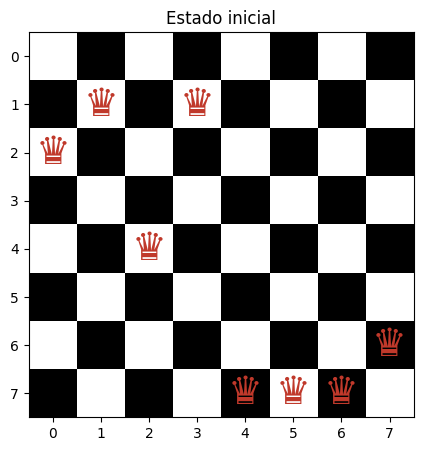

In [5]:
def plot_board(state, title=None):
    n = len(state)
    board = np.fromfunction(lambda row, col: (row + col) % 2, (n, n))
    plt.figure(figsize=(5, 5))
    plt.imshow(board, cmap="Greys", vmin=0, vmax=1)
    for col, row in enumerate(state):
        plt.text(col, row, "♛", ha="center", va="center", fontsize=28, color="#c0392b")
    plt.xticks(range(n)); plt.yticks(range(n))
    plt.title(title or str(state))
    plt.show()

initial_state = [2, 1, 4, 1, 7, 7, 7, 6]
plot_board(initial_state, "Estado inicial")

## Actividad 1 — Función de costo

Cuenta cuántos pares de reinas comparten fila o diagonal. Cada pareja debe contarse una sola vez.

In [3]:
def conflicts(state):
    """Número de pares de reinas que se atacan."""
    n = len(state)
    count = 0
    for col1 in range(n):
        for col2 in range(col1 + 1, n): 
            row1, row2 = state[col1], state[col2]
            if row1 == row2:                              # misma fila
                count += 1
            elif abs(row1 - row2) == abs(col1 - col2):     # misma diagonal
                count += 1
    return count

In [4]:
assert conflicts([0, 1, 2, 3]) == 6
assert conflicts([1, 3, 0, 2]) == 0
assert conflicts([0, 0, 2, 3]) > 0
print("Pruebas de costo superadas.")

Pruebas de costo superadas.


## Actividad 2 — Generación de vecinos

Un vecino se obtiene moviendo una reina a otra fila dentro de su misma columna.

In [6]:
def get_neighbors(state):
    """Genera todos los estados alcanzables moviendo exactamente una reina."""
    n = len(state)
    neighbors = []
    for col in range(n):
        for row in range(n):
            if row != state[col]:           # mover a la misma fila no genera un vecino nuevo
                neighbor = list(state)
                neighbor[col] = row
                neighbors.append(neighbor)
    return neighbors

In [7]:
neighbors = get_neighbors([0, 1, 2, 3])
assert len(neighbors) == 4 * 3
assert all(sum(a != b for a, b in zip([0, 1, 2, 3], n)) == 1 for n in neighbors)
print("Pruebas de vecinos superadas.")

Pruebas de vecinos superadas.


## Actividad 3 — Hill Climbing

In [8]:
def best_neighbor(state):
    """Devuelve un vecino de costo mínimo y su costo."""
    neighbors = get_neighbors(state)
    costs = [conflicts(n) for n in neighbors]
    best_cost = min(costs)
    # puede haber varios vecinos igual de buenos: desempatamos al azar para no sesgar la búsqueda
    best_candidates = [n for n, c in zip(neighbors, costs) if c == best_cost]
    return random.choice(best_candidates), best_cost


def hill_climbing(initial_state, max_steps=200):
    """Minimiza conflicts hasta solución o mínimo local."""
    current = list(initial_state)
    current_cost = conflicts(current)
    history_costs = [current_cost]

    for _ in range(max_steps):
        if current_cost == 0:                 # ya encontramos una solución
            break
        neighbor, neighbor_cost = best_neighbor(current)
        if neighbor_cost < current_cost:      # solo aceptamos mejoras estrictas
            current, current_cost = neighbor, neighbor_cost
            history_costs.append(current_cost)
        else:
            break                              # mínimo local: ningún vecino mejora, nos detenemos

    return current, history_costs

Estado final: [2, 7, 4, 1, 7, 0, 3, 6]
Costo final: 2
Pasos: 3


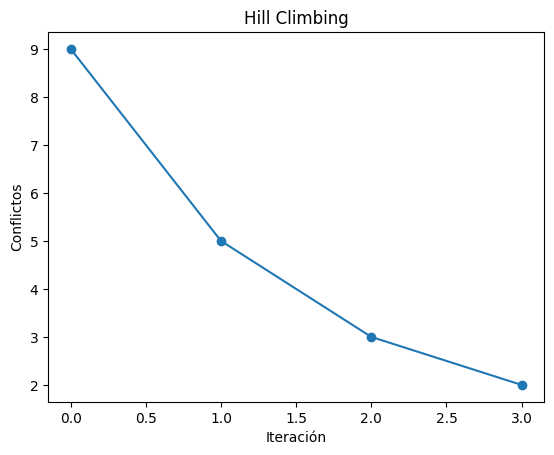

In [9]:
random.seed(RANDOM_STATE)
state_hc, costs_hc = hill_climbing(initial_state)
print("Estado final:", state_hc)
print("Costo final:", conflicts(state_hc))
print("Pasos:", len(costs_hc) - 1)

plt.plot(costs_hc, marker="o")
plt.xlabel("Iteración"); plt.ylabel("Conflictos")
plt.title("Hill Climbing")
plt.show()

## Actividad 4 — Simulated Annealing

Estamos minimizando. Define:

$$\Delta = C_{nuevo}-C_{actual}.$$

Si $\Delta\leq 0$, el movimiento no empeora. Si $\Delta>0$, se acepta con probabilidad:

$$P=\exp\left(-\frac{\Delta}{T}\right).$$

In [ ]:
def acceptance_probability(current_cost, new_cost, temperature):
    delta = new_cost - current_cost
    if delta <= 0:            # el vecino no empeora: se acepta siempre
        return 1.0
    return math.exp(-delta / temperature)   # empeora: se acepta con probabilidad decreciente


def simulated_annealing(initial_state, initial_temperature=10.0,
                        cooling_rate=0.995, min_temperature=1e-3,
                        max_steps=10_000):
    current = list(initial_state)
    current_cost = conflicts(current)
    best_state, best_cost = list(current), current_cost   # guardamos el mejor visto por si el
    history_costs = [current_cost]                        # camino final termina siendo peor
    temperature = initial_temperature

    for _ in range(max_steps):
        if current_cost == 0 or temperature < min_temperature:
            break

        neighbor = random.choice(get_neighbors(current))   # vecino aleatorio, no el mejor
        neighbor_cost = conflicts(neighbor)

        if random.random() < acceptance_probability(current_cost, neighbor_cost, temperature):
            current, current_cost = neighbor, neighbor_cost   # se acepta (mejora o "mala suerte")

        if current_cost < best_cost:
            best_state, best_cost = list(current), current_cost

        history_costs.append(current_cost)
        temperature *= cooling_rate            #Enfriamiento, entre mas iteraciones enfria menos

    return best_state, history_costs

Estado final:

 [4, 2, 0, 5, 7, 1, 3, 6]
Costo final: 0


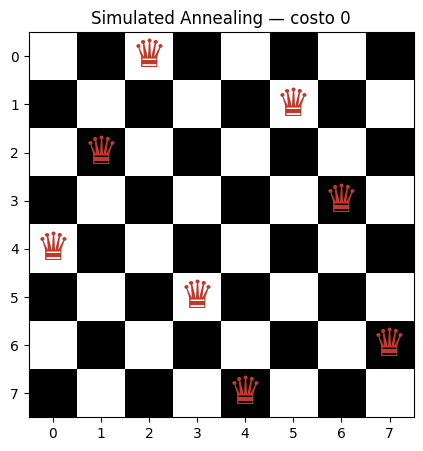

In [11]:
assert acceptance_probability(5, 4, 1.0) == 1.0
assert 0 < acceptance_probability(4, 5, 1.0) < 1

random.seed(RANDOM_STATE)
state_sa, costs_sa = simulated_annealing(initial_state)
print("Estado final:", state_sa)
print("Costo final:", conflicts(state_sa))
plot_board(state_sa, f"Simulated Annealing — costo {conflicts(state_sa)}")

## Actividad 5 — Comparación en varios reinicios

In [12]:
# Ejecuta cada algoritmo 30 veces desde estados aleatorios
# Reporta tasa de éxito (costo 0) y costo final promedio

random.seed(RANDOM_STATE)
n_runs = 30

hc_final_costs, sa_final_costs = [], []

for _ in range(n_runs):
    start_state = [random.randint(0, N - 1) for _ in range(N)]   # estado inicial al azar

    final_hc, _ = hill_climbing(start_state)
    hc_final_costs.append(conflicts(final_hc))

    final_sa, _ = simulated_annealing(start_state)
    sa_final_costs.append(conflicts(final_sa))

comparison = pd.DataFrame({
    "algoritmo": ["Hill Climbing", "Simulated Annealing"],
    "tasa_exito": [
        np.mean([c == 0 for c in hc_final_costs]),
        np.mean([c == 0 for c in sa_final_costs]),
    ],
    "costo_promedio": [np.mean(hc_final_costs), np.mean(sa_final_costs)],
})
comparison

,algoritmo,tasa_exito,costo_promedio
0,Hill Climbing,0.033333,1.366667
1,Simulated Annealing,0.800000,0.200000


## Preguntas de análisis

1. ¿Por qué Hill Climbing puede detenerse con costo mayor que cero?
2. ¿Qué permite a Simulated Annealing escapar de mínimos locales?
3. Si el enfriamiento es demasiado rápido, ¿a cuál algoritmo empieza a parecerse?
4. ¿Qué ocurre si la temperatura permanece muy alta?

## Checklist

- [ ] Implementé costo y vecinos.
- [ ] Hill Climbing acepta solo mejoras.
- [ ] Simulated Annealing puede aceptar empeoramientos.
- [ ] Comparé ambos algoritmos en múltiples ejecuciones.